# Crop Yield Prediction: Temporal Fusion Transformer

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, TensorDataset
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# Optuna Visualization Tools
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_slice
from optuna.visualization import plot_param_importances

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


c:\Users\Trin Uthaisang\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:
# ==============================
# 1. LOAD & CONFIG
# ==============================
CHOSEN_CROP = "rice" 
TARGET_COL = f"Y_{CHOSEN_CROP}"
PARQUET_PATH = 'Parquet/XY_v3.parquet'
SEQ_LEN     = 5              
BATCH_SIZE  = 32
CLIP_QUANT  = 0.01          
EPOCHS      = 100
PATIENCE    = 15
LR          = 2e-4

df = pd.read_parquet(PARQUET_PATH)
df = df[(df["year"] >= 1982) & (df["year"] <= 2023)].copy()
df = df.dropna(subset=[TARGET_COL]).copy()
print(f"--> Filtered years (1982-2023) and dropped NaN targets. New Shape: {df.shape}")

LAG_1_FEATURE = f'avg_yield_{CHOSEN_CROP}_1y'


--> Filtered years (1982-2023) and dropped NaN targets. New Shape: (4687, 75)


In [3]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. PREPROCESSING + SEQUENCE BUILDING
# ============================================================
def preprocess_and_build_loaders(
    df: pd.DataFrame,
    chosen_crop: str,
    target_col: str,
    seq_len: int = 5,
    batch_size: int = 32,
    clip_quant: float = 0.01,
):

    print("========== PREPROCESSING START ==========")
    print(f"Chosen crop: {chosen_crop}")
    print(f"Target col:  {target_col}")
    print(f"Seq len:     {seq_len}")
    print(f"Batch size:  {batch_size}")
    print("-----------------------------------------")

    df_model = df.copy()
    print(f"Initial df shape: {df_model.shape}")

    # -------------------------------------------
    # 1) Drop rows with NaN target
    # -------------------------------------------
    n_before = len(df_model)
    df_model = df_model[~df_model[target_col].isna()].copy()
    n_after = len(df_model)
    print(f"[Step 1] Dropped rows with NaN target: {n_before - n_after} rows removed")
    print(f"        Remaining rows: {n_after}")

    # -------------------------------------------
    # 1.5) Remove min/max target per country (area)
    # -------------------------------------------
    print("[Step 1.5] Removing per-area min/max target rows as outliers...")

    # ensure we still have area + target
    if "area" not in df_model.columns:
        raise ValueError("'area' column not found in df for min/max removal")

    # indices of min and max target per area
    idx_min = df_model.groupby("area")[target_col].idxmin().values
    idx_max = df_model.groupby("area")[target_col].idxmax().values

    rows_to_drop = np.unique(np.concatenate([idx_min, idx_max]))
    n_before_mm = len(df_model)
    df_model = df_model.loc[~df_model.index.isin(rows_to_drop)].reset_index(drop=True)
    n_after_mm = len(df_model)

    print(f"        Dropped {n_before_mm - n_after_mm} rows (min + max per area).")
    print(f"        Remaining rows after outlier removal: {n_after_mm}")

    # -------------------------------------------
    # 2) Target & feature selection
    # -------------------------------------------
    print("[Step 2] Target & feature selection...")
    # Drop other target columns
    all_targets = [c for c in df_model.columns if c.startswith("Y_")]
    drop_other_targets = [c for c in all_targets if c != target_col]
    df_model = df_model.drop(columns=drop_other_targets)
    print(f"        Target columns found: {all_targets}")
    print(f"        Keeping target: {target_col}")
    print(f"        Dropping other targets: {drop_other_targets}")

    # Drop unrelated avg_yield_* columns
    avg_yield_cols = [c for c in df_model.columns if c.startswith("avg_yield_")]
    chosen_prefix = f"avg_yield_{chosen_crop}_"
    keep_avg_yield = [c for c in avg_yield_cols if c.startswith(chosen_prefix)]
    drop_avg_yield = list(set(avg_yield_cols) - set(keep_avg_yield))
    df_model = df_model.drop(columns=drop_avg_yield)

    print(f"        Total avg_yield_* cols: {len(avg_yield_cols)}")
    print(f"        Keeping {len(keep_avg_yield)} for {chosen_crop}")
    print(f"        Dropping {len(drop_avg_yield)} from other crops")

    # -------------------------------------------
    # 3) Add time features (trend over years)
    # -------------------------------------------
    print("[Step 3] Adding time features year_index and year_norm...")
    base_year = df_model["year"].min()
    df_model["year_index"] = df_model["year"] - base_year
    max_index = df_model["year_index"].max() if df_model["year_index"].max() > 0 else 1
    df_model["year_norm"] = df_model["year_index"] / max_index
    print(f"        Base year: {base_year}")
    print(f"        Max year_index: {max_index}")
    print(f"        year range in df: {df_model['year'].min()}–{df_model['year'].max()}")

    # -------------------------------------------
    # 4) Sort for time consistency
    # -------------------------------------------
    print("[Step 4] Sorting by ['area', 'year']...")
    df_model = df_model.sort_values(["area", "year"]).reset_index(drop=True)
    print(f"        After sort shape: {df_model.shape}")

    # -------------------------------------------
    # 5) Define feature columns
    # -------------------------------------------
    feature_cols = [
        c
        for c in df_model.columns
        if c not in ["area", "year", target_col] and not c.startswith("Y_")
    ]
    print("[Step 5] Defining feature columns...")
    print(f"        Selected {len(feature_cols)} input features for prediction.")
    print(f"        First 10 features: {feature_cols[:10]}")

    # -------------------------------------------
    # 6) Group-wise ffill/bfill for feature columns
    # -------------------------------------------
    print("[Step 6] Group-wise ffill/bfill within each area...")
    na_before = df_model[feature_cols].isna().sum().sum()
    df_model[feature_cols] = (
        df_model.groupby("area", group_keys=False)[feature_cols]
        .apply(lambda g: g.ffill().bfill())
    )
    na_after = df_model[feature_cols].isna().sum().sum()
    print(f"        NaNs before ffill/bfill: {na_before}")
    print(f"        NaNs after  ffill/bfill: {na_after}")

    # -------------------------------------------
    # 7) Time-based masks (on rows; for scaling only)
    # -------------------------------------------
    print("[Step 7] Creating time-based masks (rows)...")
    train_mask_rows = df_model["year"] < 2014
    val_mask_rows   = (df_model["year"] >= 2014) & (df_model["year"] <= 2018)
    test_mask_rows  = df_model["year"] >= 2019

    print(f"        Train rows: {int(train_mask_rows.sum())}")
    print(f"        Val rows:   {int(val_mask_rows.sum())}")
    print(f"        Test rows:  {int(test_mask_rows.sum())}")

    # -------------------------------------------
    # 8) Raw arrays + NaN imputation (train-mean)
    # -------------------------------------------
    print("[Step 8] Building raw arrays and imputing remaining NaNs with train mean...")
    X_raw = df_model[feature_cols].values.astype(np.float32)
    y_raw = df_model[[target_col]].values.astype(np.float32)

    train_X = X_raw[train_mask_rows]
    train_mean = np.nanmean(train_X, axis=0)
    nan_inds = np.where(np.isnan(X_raw))
    n_nan_total = len(nan_inds[0])
    print(f"        Remaining NaNs before mean-impute: {n_nan_total}")
    X_raw[nan_inds] = np.take(train_mean, nan_inds[1])
    print("        NaNs after mean-impute: 0")

    # -------------------------------------------
    # 9) Outlier clipping (train-based quantiles)
    # -------------------------------------------
    if clip_quant is not None and 0.0 < clip_quant < 0.5:
        print(f"[Step 9] Clipping outliers using train quantiles {clip_quant:.2f} and {1-clip_quant:.2f}...")
        train_X_no_nan = X_raw[train_mask_rows]
        q_low = np.quantile(train_X_no_nan, clip_quant, axis=0)
        q_high = np.quantile(train_X_no_nan, 1.0 - clip_quant, axis=0)

        n_clipped_cols = 0
        for j in range(train_X_no_nan.shape[1]):
            if q_low[j] < q_high[j]:
                X_raw[:, j] = np.clip(X_raw[:, j], q_low[j], q_high[j])
                n_clipped_cols += 1
        print(f"        Columns clipped: {n_clipped_cols}/{train_X_no_nan.shape[1]}")
    else:
        print("[Step 9] Skipping clipping (clip_quant is None or invalid).")

    # -------------------------------------------
    # 10) Scaling (fit only on train)
    # -------------------------------------------
    print("[Step 10] Scaling X and y (StandardScaler, train-only fit)...")
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_scaled = X_raw.copy()
    y_scaled = y_raw.copy()

    X_scaled[train_mask_rows] = scaler_X.fit_transform(X_raw[train_mask_rows])
    X_scaled[val_mask_rows]   = scaler_X.transform(X_raw[val_mask_rows])
    X_scaled[test_mask_rows]  = scaler_X.transform(X_raw[test_mask_rows])

    y_scaled[train_mask_rows] = scaler_y.fit_transform(y_raw[train_mask_rows])
    y_scaled[val_mask_rows]   = scaler_y.transform(y_raw[val_mask_rows])
    y_scaled[test_mask_rows]  = scaler_y.transform(y_raw[test_mask_rows])

    print("        Scaling complete.")
    print(f"        y_scaled train mean (should be ~0): {y_scaled[train_mask_rows].mean():.4f}")
    print(f"        y_scaled train std  (should be ~1): {y_scaled[train_mask_rows].std():.4f}")

    # -------------------------------------------
    # 11) Rebuild scaled DataFrame for sequences
    # -------------------------------------------
    print("[Step 11] Rebuilding scaled DataFrame for sequence building...")
    df_scaled = df_model[["area", "year"]].copy()
    df_scaled["target_scaled"] = y_scaled.reshape(-1)

    X_df = pd.DataFrame(X_scaled, columns=feature_cols, index=df_model.index)
    df_final = pd.concat([df_scaled, X_df], axis=1)
    print(f"        df_final shape: {df_final.shape}")
    print("        Sample df_final head():")
    print(df_final.head())

    # -------------------------------------------
    # 12) Sequence building with split by TARGET YEAR
    # -------------------------------------------
    print("[Step 12] Building sequences and splitting by TARGET YEAR...")

    def build_sequences_by_split(
        df_seq: pd.DataFrame,
        feat_cols: list,
        target_col_name: str,
        seq_len_inner: int,
    ):
        X_train_list, y_train_list = [], []
        X_val_list, y_val_list     = [], []
        X_test_list, y_test_list   = [], []

        for _, g in df_seq.groupby("area"):
            g = g.sort_values("year")
            feats = g[feat_cols].values.astype(np.float32)
            targs = g[target_col_name].values.astype(np.float32)
            years = g["year"].values

            if len(g) < seq_len_inner:
                continue

            for i in range(len(g) - seq_len_inner + 1):
                X_seq = feats[i : i + seq_len_inner]
                y_t   = targs[i + seq_len_inner - 1]
                y_yr  = years[i + seq_len_inner - 1]

                if y_yr < 2014:
                    X_train_list.append(X_seq)
                    y_train_list.append(y_t)
                elif 2014 <= y_yr <= 2018:
                    X_val_list.append(X_seq)
                    y_val_list.append(y_t)
                else: 
                    X_test_list.append(X_seq)
                    y_test_list.append(y_t)

        def to_array(x_list, y_list):
            if len(x_list) == 0:
                return (
                    np.empty((0, seq_len_inner, len(feat_cols)), dtype=np.float32),
                    np.empty((0,), dtype=np.float32),
                )
            X_arr = np.stack(x_list).astype(np.float32)
            y_arr = np.array(y_list, dtype=np.float32)
            return X_arr, y_arr

        X_tr, y_tr = to_array(X_train_list, y_train_list)
        X_v, y_v   = to_array(X_val_list, y_val_list)
        X_te, y_te = to_array(X_test_list, y_test_list)

        return X_tr, y_tr, X_v, y_v, X_te, y_te

    X_train, y_train, X_val, y_val, X_test, y_test = build_sequences_by_split(
        df_final,
        feature_cols,
        "target_scaled",
        seq_len,
    )

    print(f"        Sequence shapes:")
    print(f"           Train: {X_train.shape}, targets: {y_train.shape}")
    print(f"           Val:   {y_val.shape}, targets: {y_val.shape}")
    print(f"           Test:  {X_test.shape}, targets: {y_test.shape}")

    # -------------------------------------------
    # 13) Build PyTorch DataLoaders
    # -------------------------------------------
    print("[Step 13] Building PyTorch DataLoaders...")

    def make_loader(X, y, batch_size_inner: int, shuffle: bool):
        X_tensor = torch.from_numpy(X) 
        y_tensor = torch.from_numpy(y).unsqueeze(-1)  
        dataset = TensorDataset(X_tensor, y_tensor)
        return DataLoader(dataset, batch_size=batch_size_inner, shuffle=shuffle)

    train_loader = make_loader(X_train, y_train, batch_size, shuffle=True)
    val_loader   = make_loader(X_val,   y_val,   batch_size, shuffle=False)
    test_loader  = make_loader(X_test,  y_test,  batch_size, shuffle=False)

    print("========== PREPROCESSING DONE ==========")
    print(f"Train sequences: {len(train_loader.dataset)}")
    print(f"Val sequences:   {len(val_loader.dataset)}")
    print(f"Test sequences:  {len(test_loader.dataset)}")
    print("========================================")

    return train_loader, val_loader, test_loader, feature_cols, scaler_y


In [4]:
def compute_baseline_rmse(df, target_col):
    """
    Compute baseline model: y(t) ≈ y(t-1)
    Using raw (unscaled) yearly panel data.
    """
    df_sorted = df.sort_values(["area", "year"]).copy()
    df_sorted["y_lag1"] = df_sorted.groupby("area")[target_col].shift(1)

    # Only test years
    test_mask = df_sorted["year"] >= 2019
    df_test = df_sorted[test_mask]

    y_true = df_test[target_col]
    y_pred = df_test["y_lag1"]

    # Drop rows where lag is not available (first year per country)
    mask = (~y_true.isna()) & (~y_pred.isna())
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]

    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    r2 = r2_score(y_true_clean, y_pred_clean)

    return rmse, r2, y_true_clean.values, y_pred_clean.values


In [5]:
# Build Transformer data loaders
train_loader, val_loader, test_loader, feature_cols, scaler_y = preprocess_and_build_loaders(
    df=df,
    chosen_crop=CHOSEN_CROP,
    target_col=TARGET_COL,
    seq_len=SEQ_LEN,
    batch_size=BATCH_SIZE,
    clip_quant=CLIP_QUANT
)

# ---- Compute baseline BEFORE training ----
rmse_baseline, r2_baseline, y_test_clean, y_pred_clean = compute_baseline_rmse(df, TARGET_COL)

print(f"\nBaseline model: RMSE={rmse_baseline:.2f}, R²={r2_baseline:.4f}")


========== PREPROCESSING START ==========
Chosen crop: rice
Target col:  Y_rice
Seq len:     5
Batch size:  32
-----------------------------------------
Initial df shape: (4687, 75)
[Step 1] Dropped rows with NaN target: 0 rows removed
        Remaining rows: 4687
[Step 1.5] Removing per-area min/max target rows as outliers...
        Dropped 246 rows (min + max per area).
        Remaining rows after outlier removal: 4441
[Step 2] Target & feature selection...
        Target columns found: ['Y_bananas', 'Y_barley', 'Y_cassava_fresh', 'Y_cucumbers_and_gherkins', 'Y_maize_corn', 'Y_oil_palm_fruit', 'Y_other_vegetables_fresh_nec', 'Y_potatoes', 'Y_rice', 'Y_soya_beans', 'Y_sugar_beet', 'Y_sugar_cane', 'Y_tomatoes', 'Y_watermelons', 'Y_wheat']
        Keeping target: Y_rice
        Dropping other targets: ['Y_bananas', 'Y_barley', 'Y_cassava_fresh', 'Y_cucumbers_and_gherkins', 'Y_maize_corn', 'Y_oil_palm_fruit', 'Y_other_vegetables_fresh_nec', 'Y_potatoes', 'Y_soya_beans', 'Y_sugar_beet',

In [6]:
class TemporalFusionTransformer(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_heads=2, dropout=0.2):
        super().__init__()

        self.input_proj = nn.Linear(input_size, hidden_size)

        self.encoder_lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            dropout=0.0,
        )

        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size),
        )

        self.decoder_lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            dropout=0.0,
        )

        self.output_proj = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1),
        )

        self.norm1 = nn.LayerNorm(hidden_size)
        self.norm2 = nn.LayerNorm(hidden_size)

    def forward(self, x):
        """
        x: (batch, seq_len, input_size)
        returns: (batch, 1) – prediction in SCALED space
        """
        # Project inputs
        x = self.input_proj(x)                 

        # Encoder LSTM
        enc_out, (h, c) = self.encoder_lstm(x) 

        # Self-attention
        attn_out, _ = self.attention(enc_out, enc_out, enc_out)  

        # Residual + norm
        x = self.norm1(enc_out + attn_out)

        # FFN + residual + norm
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)

        # Decoder LSTM
        dec_out, _ = self.decoder_lstm(x, (h, c)) 
        # Take last time step
        last_step = dec_out[:, -1, :]  

        # Project to scalar
        out = self.output_proj(last_step)  
        return out


Using device: cpu
Epoch 0/99 | Train RMSE: 1708.39 | Val RMSE: 1888.56
Epoch 10/99 | Train RMSE: 711.58 | Val RMSE: 742.31
Epoch 20/99 | Train RMSE: 621.57 | Val RMSE: 615.55
Epoch 30/99 | Train RMSE: 620.15 | Val RMSE: 542.06
Epoch 40/99 | Train RMSE: 584.84 | Val RMSE: 520.06
Epoch 50/99 | Train RMSE: 590.88 | Val RMSE: 504.11
Epoch 60/99 | Train RMSE: 576.66 | Val RMSE: 484.55
Epoch 70/99 | Train RMSE: 582.46 | Val RMSE: 486.34
Epoch 80/99 | Train RMSE: 587.88 | Val RMSE: 480.97
Epoch 90/99 | Train RMSE: 573.28 | Val RMSE: 480.91
Epoch 99/99 | Train RMSE: 576.57 | Val RMSE: 476.60
Loaded best model with Val RMSE: 471.74617446779575


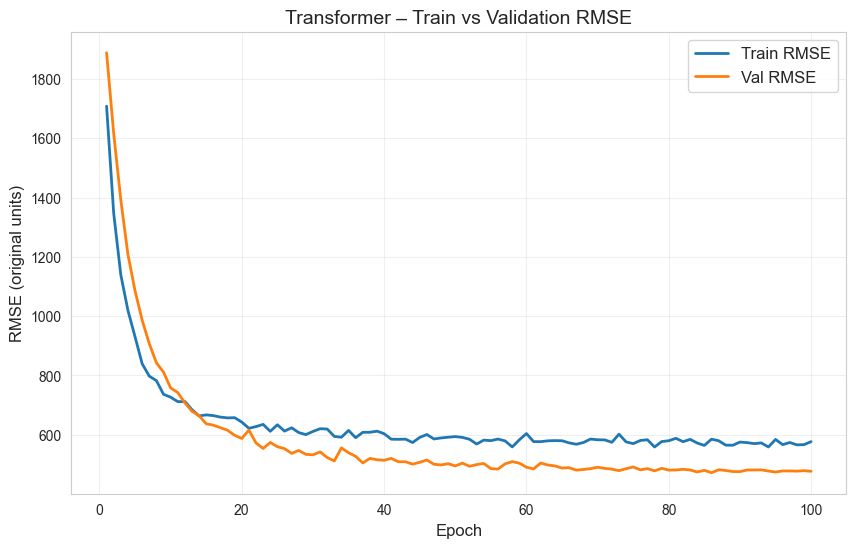

In [7]:
# ============================================================
# 3. TRAINING LOOP
# ============================================================
import copy


def rmse_unscaled(y_true_scaled, y_pred_scaled, scaler_y):
    """
    y_true_scaled, y_pred_scaled: numpy arrays in scaled space.
    Returns RMSE in ORIGINAL units.
    """
    y_true_scaled = y_true_scaled.reshape(-1, 1)
    y_pred_scaled = y_pred_scaled.reshape(-1, 1)

    y_true = scaler_y.inverse_transform(y_true_scaled).reshape(-1)
    y_pred = scaler_y.inverse_transform(y_pred_scaled).reshape(-1)

    return np.sqrt(mean_squared_error(y_true, y_pred))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

input_dim = len(feature_cols)
model = TemporalFusionTransformer(
    input_size=input_dim,
    hidden_size=32,
    num_heads=2,
    dropout=0.2,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

criterion = nn.MSELoss()

num_epochs = 100
history = {"train_rmse": [], "val_rmse": []}

best_val_rmse = float("inf")
best_state = None
patience = 20
no_improve = 0

for epoch in range(num_epochs):
    # ---------- TRAIN ----------
    model.train()
    train_y_true_scaled = []
    train_y_pred_scaled = []

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device).float()  
        y_batch = y_batch.to(device).float()  

        optimizer.zero_grad()
        outputs = model(x_batch)              

        loss = criterion(outputs, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_y_true_scaled.append(y_batch.detach().cpu().numpy())
        train_y_pred_scaled.append(outputs.detach().cpu().numpy())

    train_y_true_scaled = np.concatenate(train_y_true_scaled).reshape(-1)
    train_y_pred_scaled = np.concatenate(train_y_pred_scaled).reshape(-1)
    train_rmse = rmse_unscaled(train_y_true_scaled, train_y_pred_scaled, scaler_y)

    # ---------- VALIDATION ----------
    model.eval()
    val_y_true_scaled = []
    val_y_pred_scaled = []
    val_losses = []

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device).float()

            outputs = model(x_batch)

            loss = criterion(outputs, y_batch)
            val_losses.append(loss.item())

            val_y_true_scaled.append(y_batch.cpu().numpy())
            val_y_pred_scaled.append(outputs.cpu().numpy())

    if len(val_y_true_scaled) > 0:
        val_y_true_scaled = np.concatenate(val_y_true_scaled).reshape(-1)
        val_y_pred_scaled = np.concatenate(val_y_pred_scaled).reshape(-1)

        val_rmse = rmse_unscaled(val_y_true_scaled, val_y_pred_scaled, scaler_y)
        val_loss = np.mean(val_losses)
    else:
        val_rmse = np.nan
        val_loss = np.nan

    history["train_rmse"].append(train_rmse)
    history["val_rmse"].append(val_rmse)

    if not np.isnan(val_loss):
        scheduler.step(val_loss)

    # Early stopping on val_rmse
    if val_rmse < best_val_rmse - 1e-3:
        best_val_rmse = val_rmse
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 10 == 0 or epoch == num_epochs - 1:
        print(
            f"Epoch {epoch}/{num_epochs-1} | "
            f"Train RMSE: {train_rmse:.2f} | "
            f"Val RMSE: {val_rmse:.2f}"
        )

    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch} (best val RMSE={best_val_rmse:.2f})")
        break

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)
    print("Loaded best model with Val RMSE:", best_val_rmse)

# ============================================================
# 5. PLOT TRAIN vs VAL RMSE
# ============================================================

epochs = range(1, len(history["train_rmse"]) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, history["train_rmse"], label="Train RMSE", linewidth=2)
plt.plot(epochs, history["val_rmse"],   label="Val RMSE", linewidth=2)
plt.title("Transformer – Train vs Validation RMSE", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("RMSE (original units)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


In [8]:
# ============================================================
# 7. FINAL EVALUATION
# ============================================================
def evaluate_loader(model, loader, scaler_y, split_name=""):
    """
    Evaluate model on a given loader:
    - Inverse-transforms y and predictions.
    - Returns RMSE, MAE, R2, preds, trues.
    """
    model.eval()
    preds_scaled = []
    trues_scaled = []

    with torch.no_grad():
        for X_b, y_b in loader:
            X_b = X_b.to(device)
            pred = model(X_b).cpu().numpy()  # (batch, 1)
            preds_scaled.append(pred)
            trues_scaled.append(y_b.numpy()) # (batch, 1)

    if not preds_scaled:
        print(f"[{split_name}] No sequences.")
        return np.nan, np.nan, np.nan, np.array([]), np.array([])

    preds_scaled = np.concatenate(preds_scaled, axis=0)   # (N, 1)
    trues_scaled = np.concatenate(trues_scaled, axis=0)   # (N, 1)

    preds = scaler_y.inverse_transform(preds_scaled).ravel()
    trues = scaler_y.inverse_transform(trues_scaled).ravel()

    rmse = np.sqrt(mean_squared_error(trues, preds))
    mae = mean_absolute_error(trues, preds)
    r2  = r2_score(trues, preds)

    print(f"[{split_name}] RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.4f}")
    return rmse, mae, r2, preds, trues


print("\n=== Final Evaluation ===")
train_rmse, train_mae, train_r2, _, _ = evaluate_loader(model, train_loader, scaler_y, split_name="Train")
val_rmse,   val_mae,   val_r2,   _, _ = evaluate_loader(model, val_loader,   scaler_y, split_name="Val")
test_rmse,  test_mae,  test_r2,  p_test, t_test = evaluate_loader(model, test_loader,  scaler_y, split_name="Test")


=== Final Evaluation ===
[Train] RMSE: 428.22 | MAE: 282.22 | R²: 0.9478
[Val] RMSE: 471.75 | MAE: 313.09 | R²: 0.9524
[Test] RMSE: 509.59 | MAE: 347.53 | R²: 0.9446


In [9]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

def preprocess_and_build_loaders(
    df: pd.DataFrame,
    chosen_crop: str,
    target_col: str,
    seq_len: int = 5,
    batch_size: int = 32,
    clip_quant: float = 0.01,
):

    df_model = df.copy()

    # 1) Drop rows with NaN target
    df_model = df_model[~df_model[target_col].isna()].copy()

    # 1.5) Remove per-area min/max target rows as outliers
    if "area" not in df_model.columns:
        raise ValueError("'area' column not found in df for min/max removal")

    idx_min = df_model.groupby("area")[target_col].idxmin().values
    idx_max = df_model.groupby("area")[target_col].idxmax().values
    rows_to_drop = np.unique(np.concatenate([idx_min, idx_max]))
    df_model = df_model.loc[~df_model.index.isin(rows_to_drop)].reset_index(drop=True)

    # 2) Target & feature selection
    all_targets = [c for c in df_model.columns if c.startswith("Y_")]
    drop_other_targets = [c for c in all_targets if c != target_col]
    df_model = df_model.drop(columns=drop_other_targets)

    avg_yield_cols = [c for c in df_model.columns if c.startswith("avg_yield_")]
    chosen_prefix = f"avg_yield_{chosen_crop}_"
    keep_avg_yield = [c for c in avg_yield_cols if c.startswith(chosen_prefix)]
    drop_avg_yield = list(set(avg_yield_cols) - set(keep_avg_yield))
    df_model = df_model.drop(columns=drop_avg_yield)

    # 3) Add time features
    base_year = df_model["year"].min()
    df_model["year_index"] = df_model["year"] - base_year
    max_index = df_model["year_index"].max() if df_model["year_index"].max() > 0 else 1
    df_model["year_norm"] = df_model["year_index"] / max_index

    # 4) Sort for time consistency
    df_model = df_model.sort_values(["area", "year"]).reset_index(drop=True)

    # 5) Define feature columns
    feature_cols = [
        c
        for c in df_model.columns
        if c not in ["area", "year", target_col] and not c.startswith("Y_")
    ]

    # 6) Group-wise ffill/bfill for feature columns
    df_model[feature_cols] = (
        df_model.groupby("area", group_keys=False)[feature_cols]
        .apply(lambda g: g.ffill().bfill())
    )

    # 7) Time-based masks (on rows; for scaling only)
    train_mask_rows = df_model["year"] < 2014
    val_mask_rows   = (df_model["year"] >= 2014) & (df_model["year"] <= 2018)
    test_mask_rows  = df_model["year"] >= 2019

    # 8) Raw arrays + NaN imputation (train-mean)
    X_raw = df_model[feature_cols].values.astype(np.float32)
    y_raw = df_model[[target_col]].values.astype(np.float32)

    train_X = X_raw[train_mask_rows]
    train_mean = np.nanmean(train_X, axis=0)
    nan_inds = np.where(np.isnan(X_raw))
    X_raw[nan_inds] = np.take(train_mean, nan_inds[1])

    # 9) Outlier clipping (train-based quantiles)
    if clip_quant is not None and 0.0 < clip_quant < 0.5:
        train_X_no_nan = X_raw[train_mask_rows]
        q_low = np.quantile(train_X_no_nan, clip_quant, axis=0)
        q_high = np.quantile(train_X_no_nan, 1.0 - clip_quant, axis=0)

        for j in range(train_X_no_nan.shape[1]):
            if q_low[j] < q_high[j]:
                X_raw[:, j] = np.clip(X_raw[:, j], q_low[j], q_high[j])

    # 10) Scaling (fit only on train)
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_scaled = X_raw.copy()
    y_scaled = y_raw.copy()

    X_scaled[train_mask_rows] = scaler_X.fit_transform(X_raw[train_mask_rows])
    X_scaled[val_mask_rows]   = scaler_X.transform(X_raw[val_mask_rows])
    X_scaled[test_mask_rows]  = scaler_X.transform(X_raw[test_mask_rows])

    y_scaled[train_mask_rows] = scaler_y.fit_transform(y_raw[train_mask_rows])
    y_scaled[val_mask_rows]   = scaler_y.transform(y_raw[val_mask_rows])
    y_scaled[test_mask_rows]  = scaler_y.transform(y_raw[test_mask_rows])

    # 11) Rebuild scaled DataFrame for sequences
    df_scaled = df_model[["area", "year"]].copy()
    df_scaled["target_scaled"] = y_scaled.reshape(-1)

    X_df = pd.DataFrame(X_scaled, columns=feature_cols, index=df_model.index)
    df_final = pd.concat([df_scaled, X_df], axis=1)

    # 12) Sequence building with split by TARGET YEAR
    def build_sequences_by_split(
        df_seq: pd.DataFrame,
        feat_cols: list,
        target_col_name: str,
        seq_len_inner: int,
    ):
        X_train_list, y_train_list = [], []
        X_val_list, y_val_list     = [], []
        X_test_list, y_test_list   = [], []

        for _, g in df_seq.groupby("area"):
            g = g.sort_values("year")
            feats = g[feat_cols].values.astype(np.float32)
            targs = g[target_col_name].values.astype(np.float32)
            years = g["year"].values

            if len(g) < seq_len_inner:
                continue

            for i in range(len(g) - seq_len_inner + 1):
                X_seq = feats[i : i + seq_len_inner]
                y_t   = targs[i + seq_len_inner - 1]
                y_yr  = years[i + seq_len_inner - 1]

                if y_yr < 2014:
                    X_train_list.append(X_seq)
                    y_train_list.append(y_t)
                elif 2014 <= y_yr <= 2018:
                    X_val_list.append(X_seq)
                    y_val_list.append(y_t)
                else:  
                    X_test_list.append(X_seq)
                    y_test_list.append(y_t)

        def to_array(x_list, y_list):
            if len(x_list) == 0:
                return (
                    np.empty((0, seq_len_inner, len(feat_cols)), dtype=np.float32),
                    np.empty((0,), dtype=np.float32),
                )
            X_arr = np.stack(x_list).astype(np.float32)
            y_arr = np.array(y_list, dtype=np.float32)
            return X_arr, y_arr

        X_tr, y_tr = to_array(X_train_list, y_train_list)
        X_v, y_v   = to_array(X_val_list, y_val_list)
        X_te, y_te = to_array(X_test_list, y_test_list)

        return X_tr, y_tr, X_v, y_v, X_te, y_te

    X_train, y_train, X_val, y_val, X_test, y_test = build_sequences_by_split(
        df_final,
        feature_cols,
        "target_scaled",
        seq_len,
    )

    # 13) Build PyTorch DataLoaders
    def make_loader(X, y, batch_size_inner: int, shuffle: bool):
        X_tensor = torch.from_numpy(X)  
        y_tensor = torch.from_numpy(y).unsqueeze(-1) 
        dataset = TensorDataset(X_tensor, y_tensor)
        return DataLoader(dataset, batch_size=batch_size_inner, shuffle=shuffle)

    train_loader = make_loader(X_train, y_train, batch_size, shuffle=True)
    val_loader   = make_loader(X_val,   y_val,   batch_size, shuffle=False)
    test_loader  = make_loader(X_test,  y_test,  batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, feature_cols, scaler_y


In [10]:
# ============================================================
# 9. OPTUNA TUNING FOR TRANSFORMER HYPERPARAMETERS
# ============================================================
import optuna
import copy



def objective(trial):

    num_heads = trial.suggest_categorical("num_heads", [1, 2, 3, 4])
    head_dim  = trial.suggest_categorical("head_dim", [8, 16, 32])
    hidden_size = num_heads * head_dim          
    seq_len = trial.suggest_int("seq_len", 4, 6)
    dropout      = trial.suggest_float("dropout", 0.05, 0.4)
    lr           = trial.suggest_float("lr", 5e-5, 5e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])

    # ---- Build loaders for this seq_len ----
    train_loader_opt, val_loader_opt, test_loader_opt, feature_cols_opt, scaler_y_opt = preprocess_and_build_loaders(
    df=df,
    chosen_crop=CHOSEN_CROP,
    target_col=TARGET_COL,
    seq_len=seq_len,
    batch_size=batch_size,
    clip_quant=CLIP_QUANT
)
    # If val set is empty for this seq_len, return large loss
    if len(val_loader_opt.dataset) == 0 or len(train_loader_opt.dataset) == 0:
        return float("inf")
    
    model_t = TemporalFusionTransformer(
        input_size=len(feature_cols),
        hidden_size=hidden_size,
        num_heads=num_heads,
        dropout=dropout,
    ).to(device)

    optimizer_t = torch.optim.Adam(model_t.parameters(),lr=lr,weight_decay=weight_decay,)
    scheduler_t = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_t, mode="min", factor=0.5, patience=5)
    criterion_t = nn.MSELoss()

    max_epochs = 80     
    patience   = 10    
    best_val_rmse = float("inf")
    no_improve = 0

    for epoch in range(max_epochs):
        # -------- TRAIN --------
        model_t.train()
        train_y_true_scaled = []
        train_y_pred_scaled = []

        for x_batch, y_batch in train_loader_opt:
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device).float()

            optimizer_t.zero_grad()
            outputs = model_t(x_batch)
            loss = criterion_t(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_t.parameters(), max_norm=1.0)
            optimizer_t.step()

            train_y_true_scaled.append(y_batch.detach().cpu().numpy())
            train_y_pred_scaled.append(outputs.detach().cpu().numpy())

        # -------- VALIDATION --------
        model_t.eval()
        val_y_true_scaled = []
        val_y_pred_scaled = []
        val_losses = []

        with torch.no_grad():
            for x_batch, y_batch in val_loader_opt:
                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device).float()

                outputs = model_t(x_batch)
                loss = criterion_t(outputs, y_batch)
                val_losses.append(loss.item())

                val_y_true_scaled.append(y_batch.cpu().numpy())
                val_y_pred_scaled.append(outputs.cpu().numpy())

        if len(val_y_true_scaled) == 0:
            return float("inf")

        val_y_true_scaled = np.concatenate(val_y_true_scaled).reshape(-1)
        val_y_pred_scaled = np.concatenate(val_y_pred_scaled).reshape(-1)
        val_rmse = rmse_unscaled(val_y_true_scaled, val_y_pred_scaled, scaler_y_opt)

        scheduler_t.step(np.mean(val_losses))

        # Early stopping on val RMSE
        if val_rmse < best_val_rmse - 1e-3:
            best_val_rmse = val_rmse
            no_improve = 0
        else:
            no_improve += 1

        # Report to Optuna for pruning
        trial.report(val_rmse, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if no_improve >= patience:
            break

    return best_val_rmse

print("\n========== Starting Optuna hyperparameter tuning ==========")
# ---- Run the Optuna study ----
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25)

print("\n===== Optuna Best Trial =====")
print(f"Best Val RMSE: {study.best_value:.2f}")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")



========== Starting Optuna hyperparameter tuning ==========

[I 2025-12-18 10:33:22,251] A new study created in memory with name: no-name-42b79ced-2b1e-4cb8-8c19-c952d96a03e2


[I 2025-12-18 10:33:36,929] Trial 0 finished with value: 592.1582875380535 and parameters: {'num_heads': 3, 'head_dim': 8, 'seq_len': 6, 'dropout': 0.21327793248962873, 'lr': 6.867924118623433e-05, 'weight_decay': 9.849203689278423e-06, 'batch_size': 128}. Best is trial 0 with value: 592.1582875380535.
[I 2025-12-18 10:33:52,768] Trial 1 finished with value: 463.5132144826078 and parameters: {'num_heads': 4, 'head_dim': 32, 'seq_len': 5, 'dropout': 0.07662131854829736, 'lr': 9.873731969326558e-05, 'weight_decay': 3.927598962762673e-05, 'batch_size': 64}. Best is trial 1 with value: 463.5132144826078.
[I 2025-12-18 10:34:44,887] Trial 2 finished with value: 472.1026934100249 and parameters: {'num_heads': 1, 'head_dim': 32, 'seq_len': 6, 'dropout': 0.3368073386919065, 'lr': 0.0001670473524595332, 'weight_decay': 9.944970098911173e-05, 'batch_size': 16}. Best is trial 1 with value: 463.5132144826078.
[I 2025-12-18 10:35:04,339] Trial 3 finished with value: 438.1766909592522 and parameters


===== Optuna Best Trial =====
Best Val RMSE: 436.45
  num_heads: 2
  head_dim: 32
  seq_len: 4
  dropout: 0.16050855199178327
  lr: 0.0004826454432213418
  weight_decay: 0.00048371202070014946
  batch_size: 32



Retraining final Transformer with best hyperparameters...
{'num_heads': 2, 'head_dim': 32, 'seq_len': 4, 'dropout': 0.16050855199178327, 'lr': 0.0004826454432213418, 'weight_decay': 0.00048371202070014946, 'batch_size': 32}
[Epoch 0] Train RMSE: 1074.06 | Val RMSE: 707.94
[Epoch 10] Train RMSE: 512.91 | Val RMSE: 469.99
[Epoch 20] Train RMSE: 497.04 | Val RMSE: 470.02
[Epoch 30] Train RMSE: 477.53 | Val RMSE: 451.02
Early stopping at epoch 34 | Best Val RMSE: 429.99
Loaded best tuned model.


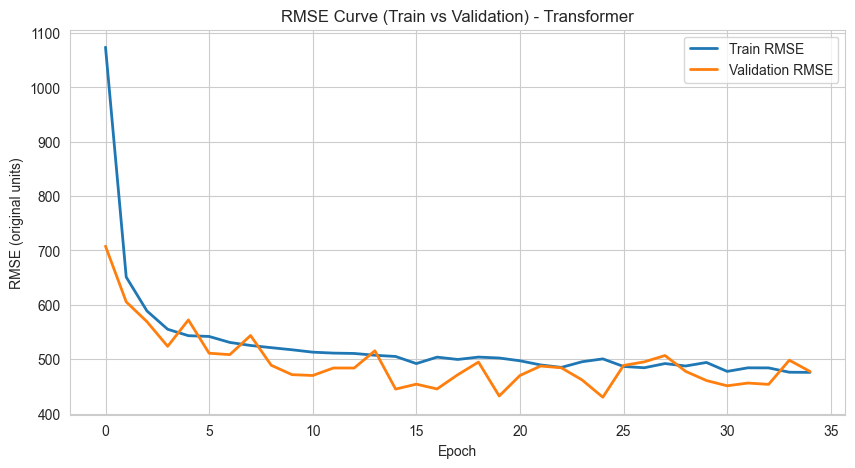


=== Final Evaluation – Tuned Transformer ===
[Train (Optuna)] RMSE: 427.45 | MAE: 288.01 | R²: 0.9474
[Val (Optuna)] RMSE: 429.99 | MAE: 304.23 | R²: 0.9605
[Test (Optuna)] RMSE: 475.88 | MAE: 321.37 | R²: 0.9516


In [21]:
# ============================================================
# 10. RETRAIN FINAL MODEL WITH BEST HYPERPARAMS + TEST
# ============================================================
best_params = study.best_params
print("\nRetraining final Transformer with best hyperparameters...")
print(best_params)

best_num_heads = best_params["num_heads"]
best_head_dim  = best_params["head_dim"]
best_hidden_size = best_num_heads * best_head_dim
best_seq_len = best_params["seq_len"]
best_dropout      = best_params["dropout"]
best_lr           = best_params["lr"]
best_weight_decay = best_params["weight_decay"]
best_batch_size = best_params["batch_size"]

# Rebuild loaders with best seq_len
train_loader_opt, val_loader_opt, test_loader_opt, feature_cols_opt, scaler_y_opt = preprocess_and_build_loaders(
    df=df,
    chosen_crop=CHOSEN_CROP,
    target_col=TARGET_COL,
    seq_len=best_seq_len,
    batch_size=best_batch_size,
    clip_quant=CLIP_QUANT,
)

# Define final model
model_opt = TemporalFusionTransformer(
    input_size=len(feature_cols_opt),
    hidden_size=best_hidden_size,
    num_heads=best_num_heads,
    dropout=best_dropout,
).to(device)

optimizer_opt = torch.optim.Adam(model_opt.parameters(),lr=best_lr,weight_decay=best_weight_decay,)
criterion_opt = nn.MSELoss()


history_opt = {"train_rmse": [],"val_rmse": [],}

best_val_rmse = float("inf")
best_state = None

patience = 10    
counter_final = 0
max_epochs = 100

for epoch in range(max_epochs):

    # ---------------------- TRAIN ----------------------
    model_opt.train()
    train_true = []
    train_pred = []

    for x_batch, y_batch in train_loader_opt:
        x_batch = x_batch.to(device).float()
        y_batch = y_batch.to(device).float()

        optimizer_opt.zero_grad()
        outputs = model_opt(x_batch)
        loss = criterion_opt(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_opt.parameters(), max_norm=1.0)
        optimizer_opt.step()

        train_true.append(y_batch.detach().cpu().numpy())
        train_pred.append(outputs.detach().cpu().numpy())

    train_true = np.concatenate(train_true).reshape(-1)
    train_pred = np.concatenate(train_pred).reshape(-1)
    train_rmse = rmse_unscaled(train_true, train_pred, scaler_y)

    # ---------------------- VALIDATION ----------------------
    model_opt.eval()
    val_true = []
    val_pred = []

    with torch.no_grad():
        for x_batch, y_batch in val_loader_opt:
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device).float()

            outputs = model_opt(x_batch)

            val_true.append(y_batch.cpu().numpy())
            val_pred.append(outputs.cpu().numpy())

    val_true = np.concatenate(val_true).reshape(-1)
    val_pred = np.concatenate(val_pred).reshape(-1)
    val_rmse = rmse_unscaled(val_true, val_pred, scaler_y)

    # Store metrics
    history_opt["train_rmse"].append(train_rmse)
    history_opt["val_rmse"].append(val_rmse)

    # Print progress every 10 epochs
    if epoch % 10 == 0 or epoch == max_epochs - 1:
        print(f"[Epoch {epoch}] Train RMSE: {train_rmse:.2f} | Val RMSE: {val_rmse:.2f}")

    # Early stopping based on RMSE
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_state = copy.deepcopy(model_opt.state_dict())
        counter_final = 0
    else:
        counter_final += 1

    if counter_final >= patience:
        print(f"Early stopping at epoch {epoch} | Best Val RMSE: {best_val_rmse:.2f}")
        break

# Load best model
if best_state is not None:
    model_opt.load_state_dict(best_state)
    print("Loaded best tuned model.")


plt.figure(figsize=(10, 5))
plt.plot(history_opt["train_rmse"], label="Train RMSE", linewidth=2)
plt.plot(history_opt["val_rmse"], label="Validation RMSE", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("RMSE (original units)")
plt.title("RMSE Curve (Train vs Validation) - Transformer")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 11. FINAL EVALUATION OF TUNED TRANSFORMER (TRAIN / VAL / TEST)
# ============================================================
print("\n=== Final Evaluation – Tuned Transformer ===")
_ = evaluate_loader(model_opt, train_loader_opt, scaler_y_opt, split_name="Train (Optuna)")
_ = evaluate_loader(model_opt, val_loader_opt, scaler_y_opt, split_name="Val (Optuna)")
_ = evaluate_loader(model_opt, test_loader_opt, scaler_y_opt, split_name="Test (Optuna)")


In [12]:
# Optuna Visualizations
name = f"{CHOSEN_CROP.capitalize()}_Yield_Transformer"

# 1. Optimization History
fig = plot_optimization_history(study)
fig.update_layout(
    title=f"{name} – Optimization History (Val RMSE)",
    xaxis_title="Trial",
    yaxis_title="Best Val RMSE",
    width=900,
    height=500,
)
fig.show()

# 2. Parallel Coordinate Plot
fig = plot_parallel_coordinate(study)
fig.update_layout(
    title=f"{name} – Parallel Coordinate Plot",
    width=900,
    height=500,
)
fig.show()

# 3. Slice Plot
fig = plot_slice(study)
fig.update_layout(
    title=f"{name} – Slice Plot",
    width=900,
    height=500,
)
fig.show()

# 4. Hyperparameter Importance
try:
    fig = plot_param_importances(study)
    fig.update_layout(
        title=f"{name} – Hyperparameter Importance",
        width=900,
        height=500,
    )
    fig.show()
except (ValueError, RuntimeError) as e:
    print(f"Could not plot parameter importance: {e}")

[Test] RMSE: 509.59 | MAE: 347.53 | R²: 0.9446
[Test (Optuna)] RMSE: 483.62 | MAE: 321.18 | R²: 0.9500

--- Final Transformer Performance Report (Test Set) ---
Baseline Model:   RMSE=536.79, R2=0.9417
Initial Transformer:     RMSE=509.59, R2=0.9446
Tuned Transformer (Opt): RMSE=483.62, R2=0.9500 (RMSE Improved 9.90%)


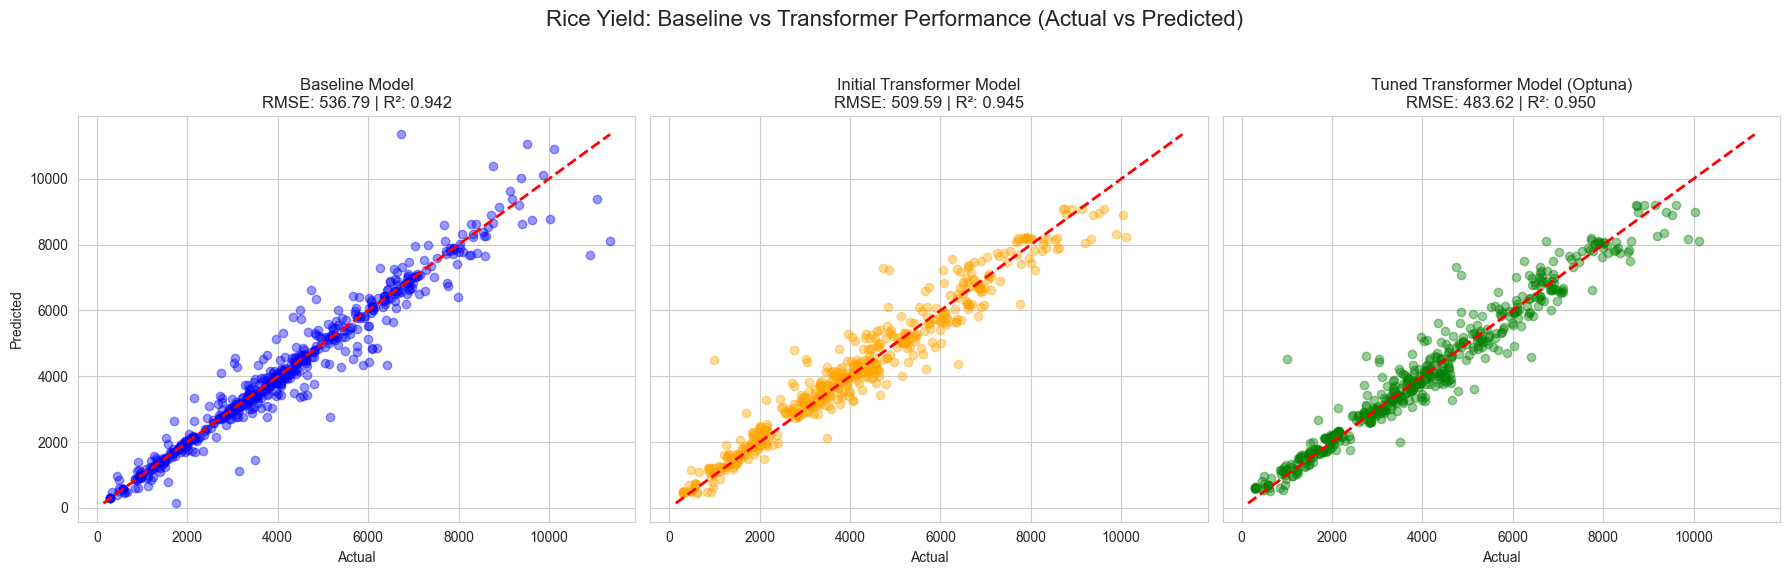

In [13]:
# ============================================================
# EVALUATE INITIAL Transformer & OPTUNA-TUNED Transformer ON TEST SET
# ============================================================

# Initial Transformer (before Optuna)
rmse_transformer_init, mae_transformer_init, r2_transformer_init, y_pred_transformer_init, y_true_transformer_init = evaluate_loader(model,test_loader,scaler_y,split_name="Test")

# Optuna-tuned Transformer (final_model)
rmse_transformer_opt, mae_transformer_opt, r2_transformer_opt, y_pred_transformer_opt, y_true_transformer_opt = evaluate_loader(model_opt, test_loader_opt, scaler_y_opt, split_name="Test (Optuna)")

# ============================================================
# PERFORMANCE REPORT vs BASELINE
# ============================================================
imp_final_transformer = (rmse_baseline - rmse_transformer_opt) / rmse_baseline * 100

print("\n--- Final Transformer Performance Report (Test Set) ---")
print(f"Baseline Model:   RMSE={rmse_baseline:.2f}, R2={r2_baseline:.4f}")
print(f"Initial Transformer:     RMSE={rmse_transformer_init:.2f}, R2={r2_transformer_init:.4f}")
print(f"Tuned Transformer (Opt): RMSE={rmse_transformer_opt:.2f}, R2={r2_transformer_opt:.4f} "
      f"(RMSE Improved {imp_final_transformer:.2f}%)")

# ============================================================
# PLOTTING: BASELINE vs INITIAL Transformer vs TUNED Transformer
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Flatten everything
y_base_true  = np.ravel(y_test_clean)
y_base_pred  = np.ravel(y_pred_clean)

y_init_true  = np.ravel(y_true_transformer_init)
y_init_pred  = np.ravel(y_pred_transformer_init)

y_opt_true   = np.ravel(y_true_transformer_opt)
y_opt_pred   = np.ravel(y_pred_transformer_opt)

# Axis limits based on all predictions and truths
all_preds = np.concatenate([y_base_pred, y_init_pred, y_opt_pred])
all_true  = np.concatenate([y_base_true, y_init_true, y_opt_true])

min_val = min(all_preds.min(), all_true.min())
max_val = max(all_preds.max(), all_true.max())

# 1. Baseline Plot
axes[0].scatter(y_base_true, y_base_pred, alpha=0.4, color='blue')
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[0].set_title(f'Baseline Model\nRMSE: {rmse_baseline:.2f} | R²: {r2_baseline:.3f}')
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# 2. Initial Transformer Plot
axes[1].scatter(y_init_true, y_init_pred, alpha=0.4, color='orange')
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[1].set_title(f'Initial Transformer Model\nRMSE: {rmse_transformer_init:.2f} | R²: {r2_transformer_init:.3f}')
axes[1].set_xlabel("Actual")

# 3. Tuned Transformer Plot
axes[2].scatter(y_opt_true, y_opt_pred, alpha=0.4, color='green')
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[2].set_title(f'Tuned Transformer Model (Optuna)\nRMSE: {rmse_transformer_opt:.2f} | R²: {r2_transformer_opt:.3f}')
axes[2].set_xlabel("Actual")

plt.suptitle(f'{CHOSEN_CROP.capitalize()} Yield: Baseline vs Transformer Performance (Actual vs Predicted)',
             fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


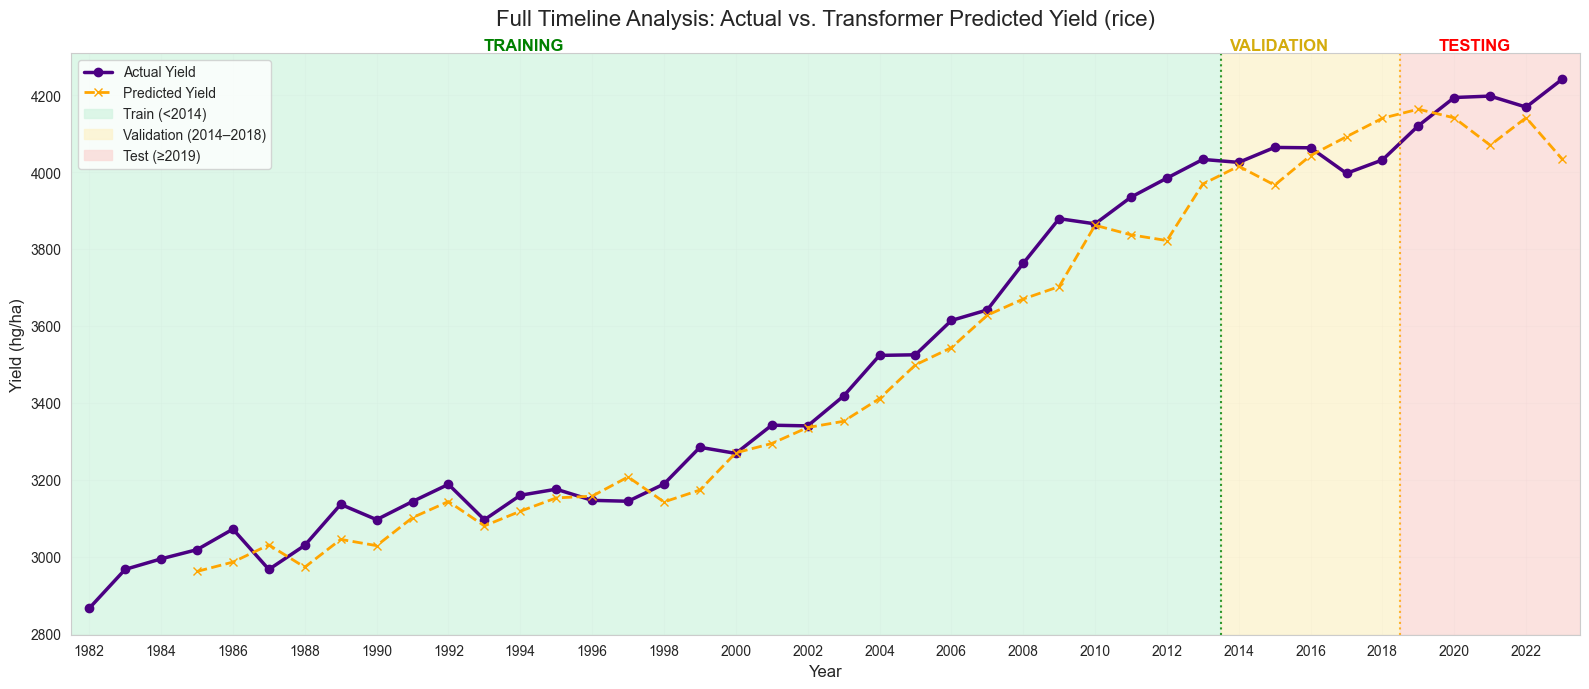

In [14]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

TRAIN_END_YEAR = 2014
VAL_END_YEAR   = 2019 

# ------------------------------------------------
# 1) Ordered loaders from Optuna data
# ------------------------------------------------
train_loader_ordered = DataLoader(train_loader_opt.dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader_ordered   = DataLoader(val_loader_opt.dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_ordered  = DataLoader(test_loader_opt.dataset,  batch_size=BATCH_SIZE, shuffle=False)

# ------------------------------------------------
# 2) Helper: get true & pred in ORIGINAL units
# ------------------------------------------------
def get_true_pred_arrays(model, loader, scaler_y):
    model.eval()
    preds_scaled, trues_scaled = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b = X_b.to(device)
            pred = model(X_b).cpu().numpy()        
            preds_scaled.append(pred)
            trues_scaled.append(y_b.numpy())      

    preds_scaled = np.concatenate(preds_scaled, axis=0).reshape(-1, 1)
    trues_scaled = np.concatenate(trues_scaled, axis=0).reshape(-1, 1)

    preds = scaler_y.inverse_transform(preds_scaled).flatten()
    trues = scaler_y.inverse_transform(trues_scaled).flatten()
    return trues, preds

# ------------------------------------------------
# 3) Build sequence YEARS in the same way as training
#    (drop NaN, remove min/max per area, keep chosen crop cols)
# ------------------------------------------------
def build_sequence_years_for_optuna(df, seq_len):
    df_model = df.copy()
    df_model = df_model[~df_model[TARGET_COL].isna()].copy()

    if "area" not in df_model.columns:
        raise ValueError("'area' column not found in df for min/max removal")

    idx_min = df_model.groupby("area")[TARGET_COL].idxmin().values
    idx_max = df_model.groupby("area")[TARGET_COL].idxmax().values
    rows_to_drop = np.unique(np.concatenate([idx_min, idx_max]))
    df_model = df_model.loc[~df_model.index.isin(rows_to_drop)].reset_index(drop=True)

    all_targets = [c for c in df_model.columns if c.startswith("Y_")]
    df_model = df_model.drop(columns=[c for c in all_targets if c != TARGET_COL])

    avg_yield_cols = [c for c in df_model.columns if c.startswith("avg_yield_")]
    chosen_prefix = f"avg_yield_{CHOSEN_CROP}_"
    keep_avg = [c for c in avg_yield_cols if c.startswith(chosen_prefix)]
    drop_avg = list(set(avg_yield_cols) - set(keep_avg))
    df_model = df_model.drop(columns=drop_avg)

    df_model = df_model.sort_values(["area", "year"]).reset_index(drop=True)

    seq_years_train, seq_years_val, seq_years_test = [], [], []

    for _, g in df_model.groupby("area"):
        g = g.sort_values("year")
        years = g["year"].values
        if len(g) < seq_len:
            continue

        for i in range(len(g) - seq_len + 1):
            yr = years[i + seq_len - 1] 
            if yr < TRAIN_END_YEAR:
                seq_years_train.append(yr)
            elif yr < VAL_END_YEAR:
                seq_years_val.append(yr)
            else:
                seq_years_test.append(yr)

    return (np.array(seq_years_train, dtype=int),
            np.array(seq_years_val,   dtype=int),
            np.array(seq_years_test,  dtype=int))

# ------------------------------------------------
# 4) Get true & predicted values from tuned Transformer
# ------------------------------------------------
y_train_true_opt, y_train_pred_opt = get_true_pred_arrays(model_opt, train_loader_ordered, scaler_y_opt)
y_val_true_opt,   y_val_pred_opt   = get_true_pred_arrays(model_opt, val_loader_ordered,   scaler_y_opt)
y_test_true_opt,  y_test_pred_opt  = get_true_pred_arrays(model_opt, test_loader_ordered,  scaler_y_opt)

# ------------------------------------------------
# 5) Target YEARS for each sequence
# ------------------------------------------------
seq_years_train_opt, seq_years_val_opt, seq_years_test_opt = build_sequence_years_for_optuna(
    df=df,
    seq_len=best_seq_len,
)

# sanity checks
assert len(seq_years_train_opt) == len(y_train_true_opt)
assert len(seq_years_val_opt)   == len(y_val_true_opt)
assert len(seq_years_test_opt)  == len(y_test_true_opt)

# ------------------------------------------------
# 6) Build yearly Transformer prediction timeline
# ------------------------------------------------
df_full_trend = pd.DataFrame({
    "Year": np.concatenate([seq_years_train_opt, seq_years_val_opt, seq_years_test_opt]),
    "Predicted": np.concatenate([y_train_pred_opt, y_val_pred_opt, y_test_pred_opt])
})

# actual yearly yield from raw df
yearly_actual = (
    df
    .groupby("year")[TARGET_COL]
    .mean()
    .rename("Actual")
)

# predicted yearly yield from Transformer
yearly_pred = (
    df_full_trend
    .groupby("Year")["Predicted"]
    .mean()
    .rename("Predicted")
)

yearly_timeline = (
    pd.concat([yearly_actual, yearly_pred], axis=1)
      .rename_axis("Year")
      .reset_index()
      .sort_values("Year")
)

yearly_timeline["Year"] = yearly_timeline["Year"].astype(int)

MIN_YEAR = int(yearly_timeline["Year"].min())
MAX_YEAR = int(yearly_timeline["Year"].max())

train_boundary = TRAIN_END_YEAR - 0.5
val_boundary   = VAL_END_YEAR   - 0.5

# ------------------------------------------------
# 7) Plot timeline: Actual vs Transformer (Train / Val / Test)
# ------------------------------------------------
plt.figure(figsize=(16, 7))
ax = plt.gca()

# Actual yield
ax.plot(
    yearly_timeline["Year"], yearly_timeline["Actual"],
    marker="o", linewidth=2.5,
    color="#4B0082",
    label="Actual Yield"
)

# Transformer predicted yield
ax.plot(
    yearly_timeline["Year"], yearly_timeline["Predicted"],
    marker="x", linestyle="--", linewidth=2.0,
    color="#FFA500",
    label="Predicted Yield"
)

# Shaded regions
ax.axvspan(MIN_YEAR - 0.5, train_boundary,
           color="#D5F5E3", alpha=0.8, label="Train (<2014)")
ax.axvspan(train_boundary, val_boundary,
           color="#FCF3CF", alpha=0.8, label="Validation (2014–2018)")
ax.axvspan(val_boundary, MAX_YEAR + 0.5,
           color="#FADBD8", alpha=0.8, label="Test (≥2019)")

# Split lines
ax.axvline(train_boundary, color="green",  linestyle=":", linewidth=1.5, alpha=0.8)
ax.axvline(val_boundary,   color="orange", linestyle=":", linewidth=1.5, alpha=0.8)

# Labels at top
ax.text(0.30, 1.00, "TRAINING",
        transform=ax.transAxes,
        ha="center", va="bottom",
        fontsize=12, fontweight="bold", color="green")
ax.text(0.80, 1.00, "VALIDATION",
        transform=ax.transAxes,
        ha="center", va="bottom",
        fontsize=12, fontweight="bold", color="#D4AC0D")
ax.text(0.93, 1.00, "TESTING",
        transform=ax.transAxes,
        ha="center", va="bottom",
        fontsize=12, fontweight="bold", color="red")

ax.set_title(f"Full Timeline Analysis: Actual vs. Transformer Predicted Yield ({CHOSEN_CROP})",
             fontsize=16, pad=20)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Yield (hg/ha)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xticks(np.arange(MIN_YEAR, MAX_YEAR + 1, 2))
ax.set_xlim(MIN_YEAR - 0.5, MAX_YEAR + 0.5)

ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()


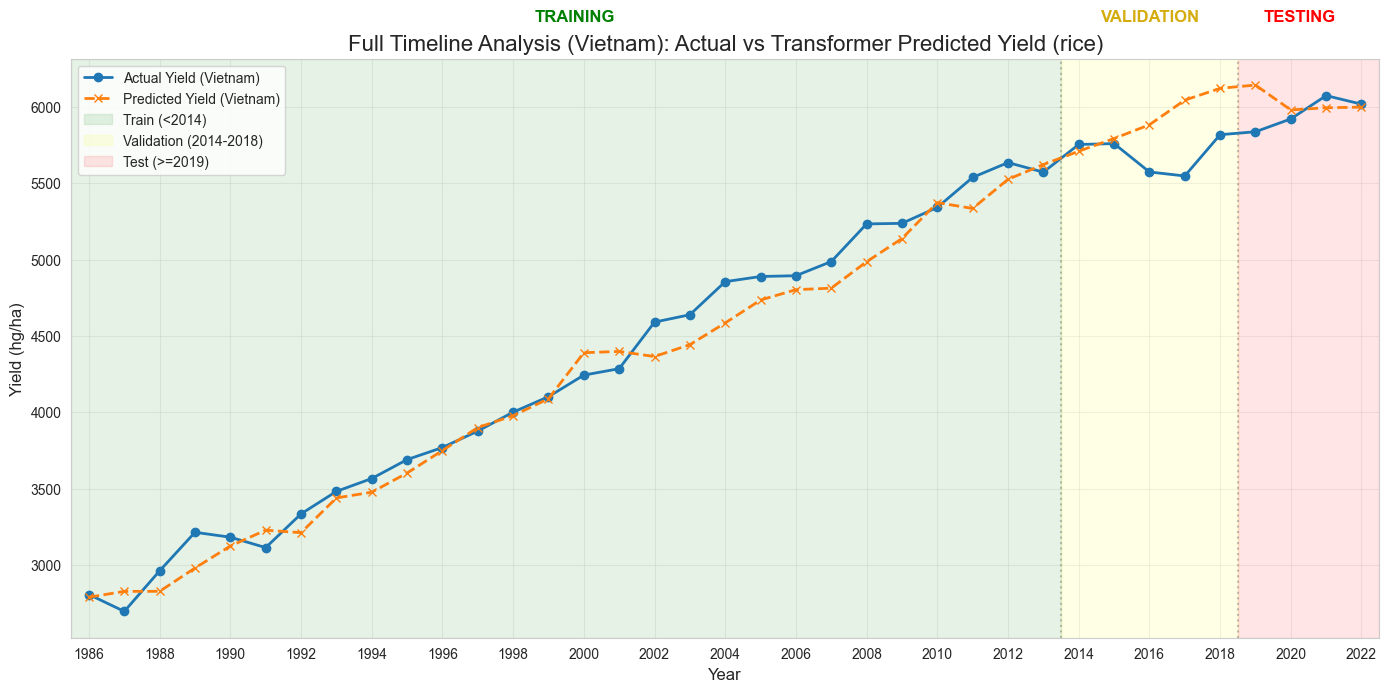

In [15]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

TRAIN_END_YEAR = 2014
VAL_END_YEAR   = 2019

# Country you want to plot
TARGET_COUNTRY = "Vietnam"

# -----------------------------
# 1) Ordered loaders
# -----------------------------
train_loader_ordered = DataLoader(train_loader_opt.dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader_ordered   = DataLoader(val_loader_opt.dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_ordered  = DataLoader(test_loader_opt.dataset,  batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# 2) Helper: get true & pred in ORIGINAL units from Transformer
# -----------------------------
def get_true_pred_arrays(model, loader, scaler_y):
    model.eval()
    preds_scaled, trues_scaled = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b = X_b.to(device)
            pred = model(X_b).cpu().numpy()   # (batch, 1)
            preds_scaled.append(pred)
            trues_scaled.append(y_b.numpy()) # (batch, 1)

    preds_scaled = np.concatenate(preds_scaled, axis=0).reshape(-1, 1)
    trues_scaled = np.concatenate(trues_scaled, axis=0).reshape(-1, 1)

    preds = scaler_y.inverse_transform(preds_scaled).ravel()
    trues = scaler_y.inverse_transform(trues_scaled).ravel()
    return trues, preds

# -----------------------------
# 3) Build (Area, Year) per sequence, same cleaning as preprocess
# -----------------------------
def build_sequence_meta_for_optuna(df, seq_len):
    df_model = df.copy()
    df_model = df_model[~df_model[TARGET_COL].isna()].copy()

    # remove per-area min/max outliers
    if "area" not in df_model.columns:
        raise ValueError("'area' column not found in df for min/max removal")

    idx_min = df_model.groupby("area")[TARGET_COL].idxmin().values
    idx_max = df_model.groupby("area")[TARGET_COL].idxmax().values
    rows_to_drop = np.unique(np.concatenate([idx_min, idx_max]))
    df_model = df_model.loc[~df_model.index.isin(rows_to_drop)].reset_index(drop=True)

    # keep only this target & its avg_yield features (shape only, not for scaling)
    all_targets = [c for c in df_model.columns if c.startswith("Y_")]
    df_model = df_model.drop(columns=[c for c in all_targets if c != TARGET_COL])

    avg_yield_cols = [c for c in df_model.columns if c.startswith("avg_yield_")]
    chosen_prefix = f"avg_yield_{CHOSEN_CROP}_"
    keep_avg = [c for c in avg_yield_cols if c.startswith(chosen_prefix)]
    drop_avg = list(set(avg_yield_cols) - set(keep_avg))
    df_model = df_model.drop(columns=drop_avg)

    # sort same as in preprocess
    df_model = df_model.sort_values(["area", "year"]).reset_index(drop=True)

    seq_areas_train, seq_years_train = [], []
    seq_areas_val,   seq_years_val   = [], []
    seq_areas_test,  seq_years_test  = [], []

    for area_name, g in df_model.groupby("area"):
        g = g.sort_values("year")
        years = g["year"].values
        if len(g) < seq_len:
            continue

        # sliding window, target at last year in window
        for i in range(len(g) - seq_len + 1):
            yr = years[i + seq_len - 1]
            if yr < TRAIN_END_YEAR:
                seq_areas_train.append(area_name)
                seq_years_train.append(yr)
            elif yr < VAL_END_YEAR:
                seq_areas_val.append(area_name)
                seq_years_val.append(yr)
            else:
                seq_areas_test.append(area_name)
                seq_years_test.append(yr)

    return (
        np.array(seq_areas_train),
        np.array(seq_years_train, dtype=int),
        np.array(seq_areas_val),
        np.array(seq_years_val,   dtype=int),
        np.array(seq_areas_test),
        np.array(seq_years_test,  dtype=int),
        df_model, 
    )

# -----------------------------
# 4) Get Transformer predictions for train/val/test
# -----------------------------
y_train_true_opt, y_train_pred_opt = get_true_pred_arrays(model_opt, train_loader_ordered, scaler_y_opt)
y_val_true_opt,   y_val_pred_opt   = get_true_pred_arrays(model_opt, val_loader_ordered,   scaler_y_opt)
y_test_true_opt,  y_test_pred_opt  = get_true_pred_arrays(model_opt, test_loader_ordered,  scaler_y_opt)

# -----------------------------
# 5) Map each sequence to (Area, Year)
# -----------------------------
(
    seq_areas_train_opt,
    seq_years_train_opt,
    seq_areas_val_opt,
    seq_years_val_opt,
    seq_areas_test_opt,
    seq_years_test_opt,
    df_clean_for_actual,
) = build_sequence_meta_for_optuna(df=df, seq_len=best_seq_len)

# sanity checks
assert len(seq_years_train_opt) == len(y_train_true_opt)
assert len(seq_years_val_opt)   == len(y_val_true_opt)
assert len(seq_years_test_opt)  == len(y_test_true_opt)

assert len(seq_areas_train_opt) == len(y_train_true_opt)
assert len(seq_areas_val_opt)   == len(y_val_true_opt)
assert len(seq_areas_test_opt)  == len(y_test_true_opt)

# -----------------------------
# 6) Build df_full_trend (Area, Year, Actual, Predicted)
# -----------------------------
# sequence-level predictions
df_pred = pd.DataFrame({
    "Area": np.concatenate([seq_areas_train_opt,  seq_areas_val_opt,  seq_areas_test_opt]),
    "Year": np.concatenate([seq_years_train_opt, seq_years_val_opt,  seq_years_test_opt]),
    "Predicted": np.concatenate([y_train_pred_opt, y_val_pred_opt, y_test_pred_opt])
})

# actual yields per Area-Year from cleaned df
df_actual = (
    df_clean_for_actual
    .groupby(["area", "year"])[TARGET_COL]
    .mean()
    .reset_index()
    .rename(columns={"area": "Area", "year": "Year", TARGET_COL: "Actual"})
)

# merge
df_full_trend = df_pred.merge(df_actual, on=["Area", "Year"], how="left")

# -----------------------------
# 7) Filter for TARGET_COUNTRY and aggregate by Year
# -----------------------------
df_th = df_full_trend[df_full_trend["Area"] == TARGET_COUNTRY].copy()

yearly_trend = (
    df_th
    .groupby("Year")[["Actual", "Predicted"]]
    .mean()
)

if yearly_trend.empty:
    print(f"No data for {TARGET_COUNTRY}")
else:
    # -----------------------------
    # 8) Plot
    # -----------------------------
    plt.figure(figsize=(14, 7))

    # Lines
    plt.plot(
        yearly_trend.index, yearly_trend["Actual"],
        marker="o", label=f"Actual Yield ({TARGET_COUNTRY})", linewidth=2
    )
    plt.plot(
        yearly_trend.index, yearly_trend["Predicted"],
        marker="x", linestyle="--", label=f"Predicted Yield ({TARGET_COUNTRY})", linewidth=2
    )

    MIN_YEAR = int(yearly_trend.index.min())
    MAX_YEAR = int(yearly_trend.index.max())

    train_boundary = TRAIN_END_YEAR - 0.5
    val_boundary   = VAL_END_YEAR   - 0.5

    # Shaded regions
    plt.axvspan(MIN_YEAR - 0.5, train_boundary, color="green",  alpha=0.1,
                label=f"Train (<{TRAIN_END_YEAR})")
    plt.axvspan(train_boundary, val_boundary,   color="yellow", alpha=0.1,
                label=f"Validation ({TRAIN_END_YEAR}-{VAL_END_YEAR-1})")
    plt.axvspan(val_boundary,   MAX_YEAR + 0.5, color="red",    alpha=0.1,
                label=f"Test (>={VAL_END_YEAR})")

    # Split lines
    plt.axvline(train_boundary, color="grey", linestyle=":", alpha=0.5)
    plt.axvline(val_boundary,   color="grey", linestyle=":", alpha=0.5)

    # Text labels
    y_max = np.nanmax(yearly_trend["Actual"])
    text_y = y_max * 1.08

    plt.text((MIN_YEAR + train_boundary)/2, text_y, "TRAINING",
             ha="center", fontsize=12, fontweight="bold", color="green")
    plt.text((train_boundary + val_boundary)/2, text_y, "VALIDATION",
             ha="center", fontsize=12, fontweight="bold", color="#D4AC0D")
    plt.text((val_boundary + MAX_YEAR)/2, text_y, "TESTING",
             ha="center", fontsize=12, fontweight="bold", color="red")

    # Formatting
    plt.title(
        f"Full Timeline Analysis ({TARGET_COUNTRY}): Actual vs Transformer Predicted Yield ({CHOSEN_CROP})",
        fontsize=16
    )
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Yield (hg/ha)", fontsize=12)
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)

    plt.xticks(np.arange(MIN_YEAR, MAX_YEAR + 1, 2))
    plt.xlim(MIN_YEAR - 0.5, MAX_YEAR + 0.5)

    plt.tight_layout()
    plt.show()


In [16]:
# ============================================
# Build comparison_df_latest for ERROR MAP
# (one test point per country at its latest test year)
# ============================================

# 1) Base comparison_df for TEST ONLY (sequence-level)
comparison_df = pd.DataFrame({
    "area":  seq_areas_test_opt,
    "year":  seq_years_test_opt,
    "Actual_Value":    y_test_true_opt,
    "Predicted_Value": y_test_pred_opt,
})

# 2) Keep only the LATEST test year per country
latest_year_per_area = comparison_df.groupby("area")["year"].transform("max")
comparison_df_latest = comparison_df[comparison_df["year"] == latest_year_per_area].copy()

# 3) (Optional) add error columns for mapping
comparison_df_latest["Abs_Error"] = (
    comparison_df_latest["Predicted_Value"] - comparison_df_latest["Actual_Value"]
).abs()

comparison_df_latest["APE"] = 100 * comparison_df_latest["Abs_Error"] / (
    comparison_df_latest["Actual_Value"].replace(0, np.nan)
)

print(comparison_df_latest.head())


           area  year  Actual_Value  Predicted_Value   Abs_Error       APE
3   Afghanistan  2022   4625.000000      4550.708008   74.291992  1.606313
8       Algeria  2023   1790.300049      1734.138794   56.161255  3.136974
13       Angola  2023   1172.100098      1185.618164   13.518066  1.153320
17    Argentina  2023   6723.700195      6902.516113  178.815918  2.659487
21    Australia  2023   9516.200195      8907.394531  608.805664  6.397571


In [17]:
import numpy as np
import pandas as pd
import plotly.express as px


# --- 1. Compute error metrics for each row ---
comparison_df_latest = comparison_df_latest.copy()
comparison_df_latest["Abs_Error"] = (
    comparison_df_latest["Predicted_Value"] - comparison_df_latest["Actual_Value"]
).abs()

# Avoid division by zero
comparison_df_latest["APE"] = 100 * comparison_df_latest["Abs_Error"] / (
    comparison_df_latest["Actual_Value"].replace(0, np.nan)
)

# --- 2. Aggregate to one row per country (mean over sequences) ---
country_error = (
    comparison_df_latest
    .groupby("area")
    .agg(
        Mean_Actual=("Actual_Value", "mean"),
        Mean_Predicted=("Predicted_Value", "mean"),
        MAE=("Abs_Error", "mean"),
        MAPE=("APE", "mean")
    )
    .reset_index()
)

print(country_error.head())

          area  Mean_Actual  Mean_Predicted         MAE      MAPE
0  Afghanistan  4625.000000     4550.708008   74.291992  1.606313
1      Algeria  1790.300049     1734.138794   56.161255  3.136974
2       Angola  1172.100098     1185.618164   13.518066  1.153320
3    Argentina  6723.700195     6902.516113  178.815918  2.659487
4    Australia  9516.200195     8907.394531  608.805664  6.397571


In [18]:
rmse_by_country = (
    comparison_df
    .groupby('area')
    .apply(lambda x: np.sqrt(np.mean((x['Actual_Value'] - x['Predicted_Value'])**2)))
    .reset_index(name='RMSE')
)

# --- Sort from highest error (worst) to lowest error (best) ---
rmse_high_to_low = rmse_by_country.sort_values(by='RMSE', ascending=False)

# --- Sort from lowest error (best) to highest error (worst) ---
rmse_low_to_high = rmse_by_country.sort_values(by='RMSE', ascending=True)

# --- Print ---
print("\n🔴 RMSE by country: Highest → Lowest\n")
print(rmse_high_to_low)



🔴 RMSE by country: Highest → Lowest

             area         RMSE
54        Jamaica  3513.525879
65      Mauritius  1494.140259
98     Tajikistan  1423.777710
57          Kenya  1264.603394
79       Paraguay  1246.928955
..            ...          ...
0     Afghanistan   100.180290
27  Côte d'Ivoire    95.807747
1         Algeria    81.570312
42      Guatemala    79.905670
99       Thailand    74.348389

[115 rows x 2 columns]


C:\Users\Trin Uthaisang\AppData\Local\Temp\ipykernel_23188\361403830.py:4: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [19]:
import numpy as np
import pandas as pd
import plotly.express as px

df_map = comparison_df.copy() 


# Squared error and percentage error
df_map['Squared_Error'] = (df_map['Actual_Value'] - df_map['Predicted_Value']) ** 2
df_map['Error_Pct'] = (
    (df_map['Actual_Value'] - df_map['Predicted_Value']) / (df_map['Actual_Value'] + 1e-6)
) ** 2

map_data = df_map.groupby('area').agg(
    RMSPE=('Error_Pct', lambda x: np.sqrt(x.mean()) * 100),
    RMSE=('Squared_Error', lambda x: np.sqrt(x.mean())),
    Actual_Mean=('Actual_Value', 'mean'),
    Predicted_Mean=('Predicted_Value', 'mean')
).reset_index()

map_data.rename(columns={'area': 'Country'}, inplace=True)

fig = px.choropleth(
    map_data,
    locations='Country',
    locationmode='country names',
    color='RMSPE',
    color_continuous_scale=['green', 'red'],
    range_color=[0, 50],
    title='Prediction Error by Country (RMSPE, Test Period)',
    hover_data={
        'RMSPE': ':.2f',
        'RMSE': ':.2f',
        'Actual_Mean': ':.2f',
        'Predicted_Mean': ':.2f'
    }
)

fig.show()

C:\Users\Trin Uthaisang\AppData\Local\Temp\ipykernel_23188\1517562050.py:23: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



Baseline RMSE = 483.6221
Testing feature: avg_yield_rice_1y
Testing feature: avg_yield_rice_2y
Testing feature: avg_yield_rice_3y
Testing feature: rain_annual
Testing feature: rain_sin
Testing feature: rain_cos
Testing feature: solar_annual
Testing feature: solar_sin
Testing feature: solar_cos
Testing feature: temp_annual
Testing feature: temp_sin
Testing feature: temp_cos
Testing feature: pesticides_lag1
Testing feature: fertilizer_lag1
Testing feature: latitude
Testing feature: longitude
Testing feature: year_index
Testing feature: year_norm


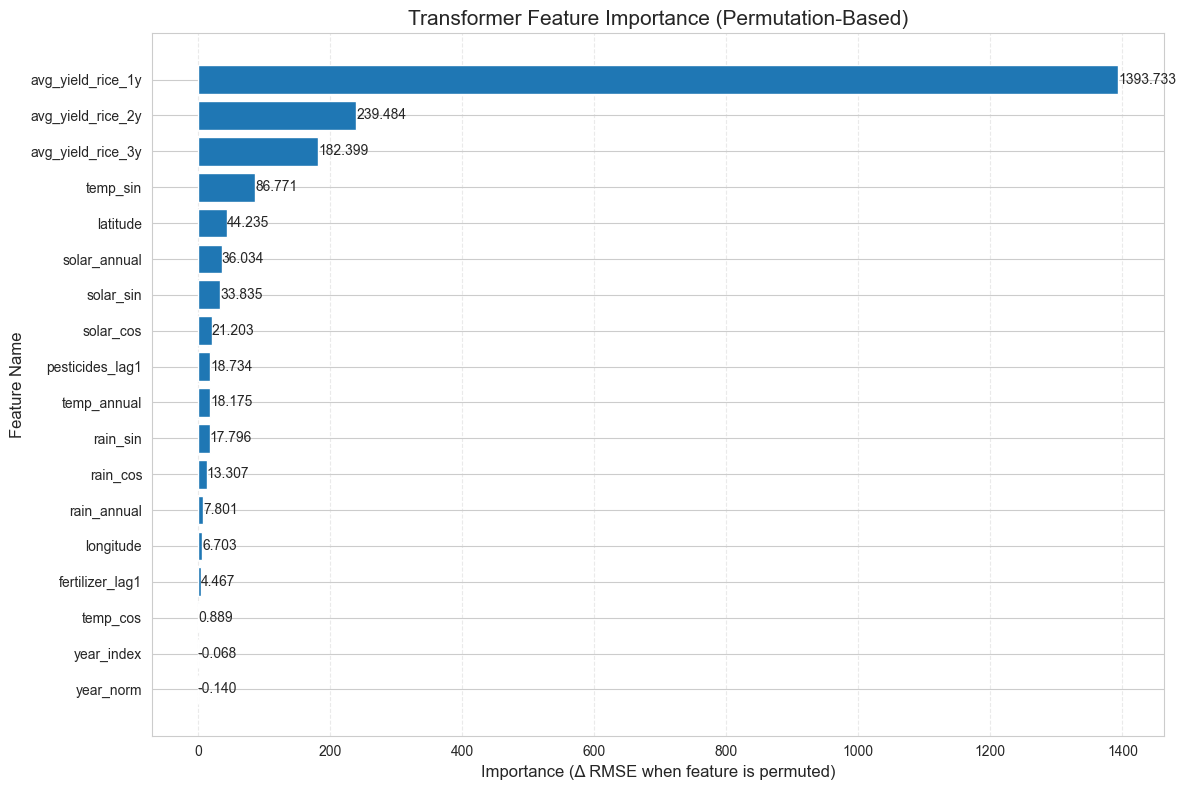

In [20]:

import numpy as np
import torch
import matplotlib.pyplot as plt
from copy import deepcopy

# ============================================================
# 1) PERMUTATION IMPORTANCE FUNCTION (Transformer)
# ============================================================
def Transformer_permutation_importance(model, test_loader, scaler_y, feature_names, device):
    model.eval()

    # --- Helper: compute RMSE on a loader ---
    def get_rmse(loader):
        preds, trues = [], []
        with torch.no_grad():
            for X_b, y_b in loader:
                X_b = X_b.to(device)
                pred = model(X_b).cpu().numpy()
                pred = scaler_y.inverse_transform(pred)
                true = scaler_y.inverse_transform(y_b.numpy())
                preds.append(pred)
                trues.append(true)
        preds = np.concatenate(preds).ravel()
        trues = np.concatenate(trues).ravel()
        return np.sqrt(np.mean((preds - trues)**2))

    # --- Baseline performance ---
    baseline_rmse = get_rmse(test_loader)
    print(f"Baseline RMSE = {baseline_rmse:.4f}")

    importances = []

    # --- Extract full dataset once ---
    X_full = []
    y_full = []
    for X_b, y_b in test_loader:
        X_full.append(X_b.clone())
        y_full.append(y_b.clone())
    X_full = torch.cat(X_full, dim=0)
    y_full = torch.cat(y_full, dim=0)

    N, seq_len, F = X_full.shape

    # --- Loop through each feature ---
    for f_idx, f_name in enumerate(feature_names):
        print(f"Testing feature: {f_name}")

        # Copy data
        X_perm = X_full.clone()

        # Shuffle ONLY that feature across all sequences
        shuffled = X_perm[:, :, f_idx].cpu().numpy()
        np.random.shuffle(shuffled)
        X_perm[:, :, f_idx] = torch.tensor(shuffled)

        # Build loader
        perm_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X_perm, y_full),
            batch_size=test_loader.batch_size,
            shuffle=False
        )

        # New RMSE
        perm_rmse = get_rmse(perm_loader)

        # Importance = RMSE increase
        importance = perm_rmse - baseline_rmse
        importances.append((f_name, importance))

    # Sort by importance (highest on top)
    importances_sorted = sorted(importances, key=lambda x: x[1], reverse=True)
    return importances_sorted


# ============================================================
# 2) RUN IMPORTANCE + BAR CHART
# ============================================================
# Run importance calculation
importances = Transformer_permutation_importance(
    model_opt,
    test_loader_ordered,   
    scaler_y_opt,
    feature_cols,          
    device
)

# Unpack into lists
feat_names  = [x[0] for x in importances]
feat_scores = [x[1] for x in importances]

# ============================================================
# 3) Plot Bar Chart
# ============================================================
plt.figure(figsize=(12, 8))

bars = plt.barh(feat_names, feat_scores, color="#1f77b4")

# Add numeric labels
for bar, score in zip(bars, feat_scores):
    plt.text(score + 0.01, bar.get_y() + bar.get_height()/2,
             f"{score:.3f}", va="center", fontsize=10)

plt.xlabel("Importance (Δ RMSE when feature is permuted)", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.title("Transformer Feature Importance (Permutation-Based)", fontsize=15)
plt.grid(axis="x", linestyle="--", alpha=0.4)

# Highest importance at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()
